##Car Price Prediction with Machine Learning

Collect car-related features like brand goodwill, horsepower, mileage, etc.

Train a regression model to predict car prices based on these features.

Handle data preprocessing, feature engineering, and model evaluation

Use Python libraries like Pandas, Scikit-learn and Matplotlib for the workflow.

Understand real-world applications of machine learning in price prediction.


In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv('/content/drive/MyDrive/clideo.com/car data.csv')
print(df)

    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  
1         Dealer       Manual    

In [8]:
print(df.info)

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  
1

In [11]:
print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())



Dataset Shape
(301, 9)

Missing Values
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [9]:
# ==========================================================
# CAR PRICE PREDICTION USING MACHINE LEARNING
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import GridSearchCV

import joblib

In [12]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

CURRENT_YEAR = 2025

df["Car_Age"] = CURRENT_YEAR - df["Year"]

df.drop("Year", axis=1, inplace=True)

In [13]:
# ==========================================================
# DEFINE FEATURES
# ==========================================================

X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]


In [14]:
# ==========================================================
# CATEGORICAL & NUMERICAL COLUMNS
# ==========================================================

categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(exclude="object").columns


In [15]:
# ==========================================================
# PREPROCESSING
# ==========================================================

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categorical_features),
    ("num", numerical_transformer, numerical_features)
])

In [16]:
# ==========================================================
# SPLIT DATA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
# ==========================================================
# RANDOM FOREST PIPELINE
# ==========================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [18]:
# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

parameters = {

    "model__n_estimators":[100,200],

    "model__max_depth":[5,10,None],

    "model__min_samples_split":[2,5]

}

grid = GridSearchCV(

    rf_pipeline,

    parameters,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print("\nBest Parameters")

print(grid.best_params_)

model = grid.best_estimator_


Best Parameters
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [19]:
# ==========================================================
# PREDICTION
# ==========================================================

predictions = model.predict(X_test)

# ==========================================================
# EVALUATION
# ==========================================================

mae = mean_absolute_error(y_test,predictions)

mse = mean_squared_error(y_test,predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,predictions)

print("\nModel Performance")

print("MAE :",round(mae,3))

print("RMSE:",round(rmse,3))

print("R2 Score:",round(r2,4))


Model Performance
MAE : 0.626
RMSE: 0.913
R2 Score: 0.9638


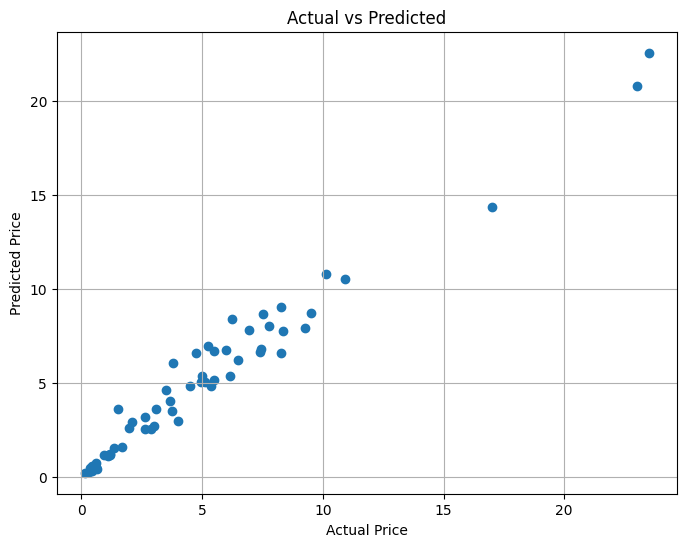

In [20]:
# ==========================================================
# VISUALIZATION
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test,predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.grid()

plt.show()

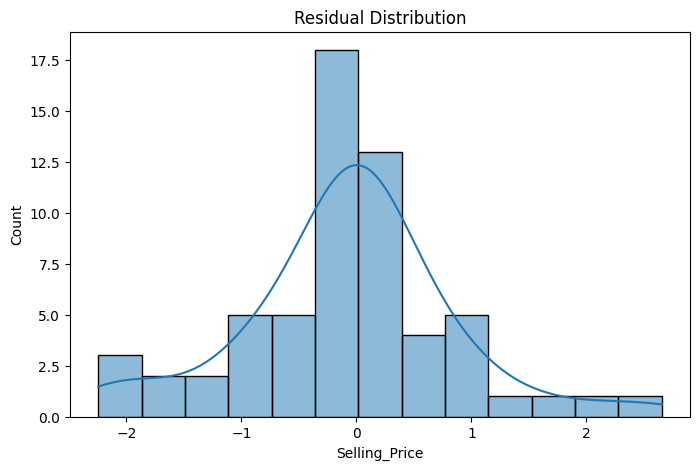

In [21]:
# ==========================================================
# RESIDUAL PLOT
# ==========================================================

residuals = y_test-predictions

plt.figure(figsize=(8,5))

sns.histplot(residuals,kde=True)

plt.title("Residual Distribution")

plt.show()


In [22]:
# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(model,"car_price_prediction.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


##Checking...

In [23]:
import pandas as pd
import joblib

model = joblib.load("car_price_prediction.pkl")

sample = pd.DataFrame({

    "Car_Name":["city"],

    "Present_Price":[9.40],

    "Driven_kms":[45000],

    "Fuel_Type":["Petrol"],

    "Selling_type":["Dealer"],

    "Transmission":["Manual"],

    "Owner":[0],

    "Car_Age":[5]

})

prediction = model.predict(sample)

print("Predicted Selling Price =", round(prediction[0],2),"Lakhs")

Predicted Selling Price = 7.84 Lakhs
